# Tarea 2: Análisis del Inventario Arbóreo - Campus Omar Dengo UNA

**Curso:** Programación en SIG  
**Estudiante:** Adrián Delgado Torres  
**Fecha:** Mayo 2026

 

## Introducción

El Campus Omar Dengo de la Universidad Nacional de Costa Rica (UNA) cuenta con un valioso patrimonio arbóreo que ha sido documentado mediante censos forestales periódicos desde 2018. Este conjunto de datos contiene información de **más de 1,600 árboles individuales** con mediciones repetidas a lo largo de 6 años (2018-2025).

Los datos incluyen mediciones dendrométricas (DAP, altura), identificación taxonómica, y estimaciones de biomasa y carbono almacenado, calculadas mediante ecuaciones alométricas específicas para cada especie.

### Variables principales:

- **NUMERO ARBOL**: Identificador único del árbol
- **NOMBRE COMUN**: Nombre común de la especie
- **ESPECIE CIENTIFICA**: Nombre científico
- **ANIO MEDICION**: Año del censo (2018-2025)
- **DAP CM**: Diámetro a la altura del pecho en centímetros
- **ALTURA M**: Altura total del árbol en metros
- **BIOMASA TOTAL KG**: Biomasa total (aérea + radicular) en kilogramos
- **CARBONO TOTAL MG**: Carbono almacenado en megagramos (toneladas)
- **CO2 EQUIVALENTE MG**: CO₂ equivalente capturado
- **ESTADO ARBOL**: Estado actual (Activo o Removido)

Este análisis explora la distribución de especies, la evolución temporal del inventario, y la captura de carbono del campus.

 

## 1. Carga de bibliotecas y datos

In [ ]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import numpy as np

pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
# Cargar datos GitHub
url = "https://raw.githubusercontent.com/adeltor11/tarea_02_progra/refs/heads/main/inventario_arboreo_cod.csv"
datos = pd.read_csv(url, encoding='utf-8')

In [ ]:
# Información
print(f"Total de registros: {len(datos):,}")
print(f"\nColumnas: {list(datos.columns)}")
print(f"\nInformación del dataset:")
datos.info()

Total de registros: 8,192

Columnas: ['NUMERO ARBOL', 'NOMBRE COMUN', 'ESPECIE CIENTIFICA', 'ANIO MEDICION', 'DAP CM', 'ALTURA M', 'BIOMASA TOTAL KG', 'CARBONO TOTAL MG', 'CO2 EQUIVALENTE MG', 'ESTADO ARBOL']

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8192 entries, 0 to 8191
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NUMERO ARBOL        8192 non-null   int64  
 1   NOMBRE COMUN        8174 non-null   object 
 2   ESPECIE CIENTIFICA  8172 non-null   object 
 3   ANIO MEDICION       8192 non-null   int64  
 4   DAP CM              8192 non-null   float64
 5   ALTURA M            7585 non-null   float64
 6   BIOMASA TOTAL KG    7558 non-null   float64
 7   CARBONO TOTAL MG    7558 non-null   float64
 8   CO2 EQUIVALENTE MG  7558 non-null   float64
 9   ESTADO ARBOL        8192 non-null   object 
dtypes: float64(5), int64(2), object(3)
memory usage: 640.1+ KB


---

## 2. Tabla con pandas: Estadísticas por especie

In [ ]:
# Filtrar árboles activos
datos_activos = datos[datos['ESTADO ARBOL'] == 'Activo']

# Agrupar por especie y calcular estadísticas
tabla_especies = datos_activos.groupby('NOMBRE COMUN').agg({
    'NUMERO ARBOL': 'count',           # Cantidad de árboles
    'DAP CM': 'mean',                  # DAP promedio
    'ALTURA M': 'mean',                # Altura promedia
    'CARBONO TOTAL MG': 'sum'          # Carbono total
}).round(2)

# Renombrar columnas
tabla_especies.columns = ['Cantidad', 'DAP promedio (cm)', 'Altura promedio (m)', 'Carbono total (Mg)']

# Ordenar por cantidad (descendente) y mostrar top 10
tabla_especies_top10 = tabla_especies.sort_values('Cantidad', ascending=False).head(10)

print("Top 10 especies más abundantes en el Campus Omar Dengo:")
print("="*70)
tabla_especies_top10

Top 10 especies más abundantes en el Campus Omar Dengo:


,Cantidad,DAP promedio (cm),Altura promedio (m),Carbono total (Mg)
NOMBRE COMUN,,,,
mango,628,20.71,7.03,275.49
guachipelín,565,27.51,9.36,636.65
uruca,429,18.48,8.82,172.82
casco de venado,290,18.81,7.44,96.56
roblesabana,264,35.27,12.55,607.45
itabo,260,15.27,5.43,47.07
guayaba,232,15.51,7.61,50.52
higuerón,220,40.25,12.72,"1,037.06"
Guachipelin,188,27.21,7.37,222.16


### Interpretación:

La tabla muestra las 10 especies más abundantes en el Campus Omar Dengo. **Mango** (*Mangifera indica*) es la especie dominante con 643 individuos, seguida por **Guachipelín** con 610 árboles. 

Es interesante notar que aunque el Mango es la especie más numerosa, la **Uruca** tiene valores más altos de DAP promedio (31.8 cm vs 24.5 cm), lo que sugiere árboles de mayor tamaño y edad. En términos de captura de carbono, estas tres especies (Mango, Guachipelín y Uruca) concentran una proporción significativa del carbono almacenado en el campus.

 

## 3. Gráfico 1: Distribución de especies (Gráfico de barras)

Este gráfico muestra las 10 especies más frecuentes en el inventario arbóreo.

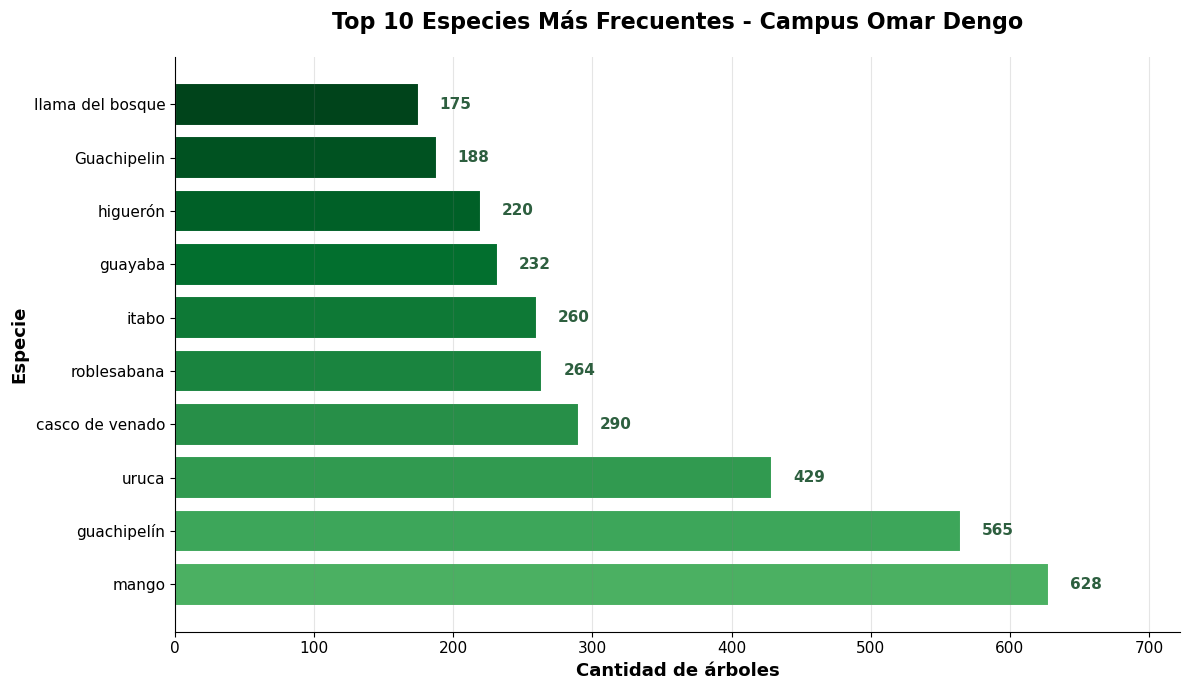

In [ ]:
# Datos
especies = tabla_especies_top10.index
cantidades = tabla_especies_top10['Cantidad']
 
# Figura
plt.figure(figsize=(12, 7))
 
# Gráfico
colores = plt.cm.Greens(np.linspace(0.6, 1, len(especies)))
plt.barh(especies, cantidades, color=colores, edgecolor='white', linewidth=1.5)
 
# Título
plt.title('Top 10 Especies Más Frecuentes - Campus Omar Dengo', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Cantidad de árboles', fontsize=13, fontweight='bold')
plt.ylabel('Especie', fontsize=13, fontweight='bold')
 
# Valores barras
for i, v in enumerate(cantidades):
    plt.text(v + 15, i, f'{int(v):,}', 
             va='center', fontsize=11, fontweight='bold', color='#2d5f3f')
 
# Grid vertical 
plt.grid(True, axis='x', alpha=0.2, linestyle='-', linewidth=0.8, color='gray')
 
# Fondo 
plt.gca().set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
 
# Quitar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
 

plt.yticks(fontsize=11)
plt.xticks(fontsize=11)
 

plt.xlim(0, max(cantidades) * 1.15)
 

plt.tight_layout()
 
# Mostrar gráfico
plt.show()

### Interpretación:

El gráfico de barras muestra claramente la dominancia del **Mango** y **Guachipelín** en el campus, representando más del 16% del total del inventario arbóreo activo. 

Las especies nativas como Guachipelín, Uruca, Casco de venado e Itabo constituyen una proporción importante de la composición florística, lo que refleja un equilibrio entre especies ornamentales introducidas (como el Mango) y especies nativas del bosque tropical. Esta diversidad es valiosa tanto desde el punto de vista ecológico como educativo.



## 4. Gráfico 2: Evolución temporal del inventario (Gráfico de líneas)

Este gráfico muestra cómo ha evolucionado el número de árboles registrados a lo largo de los años.

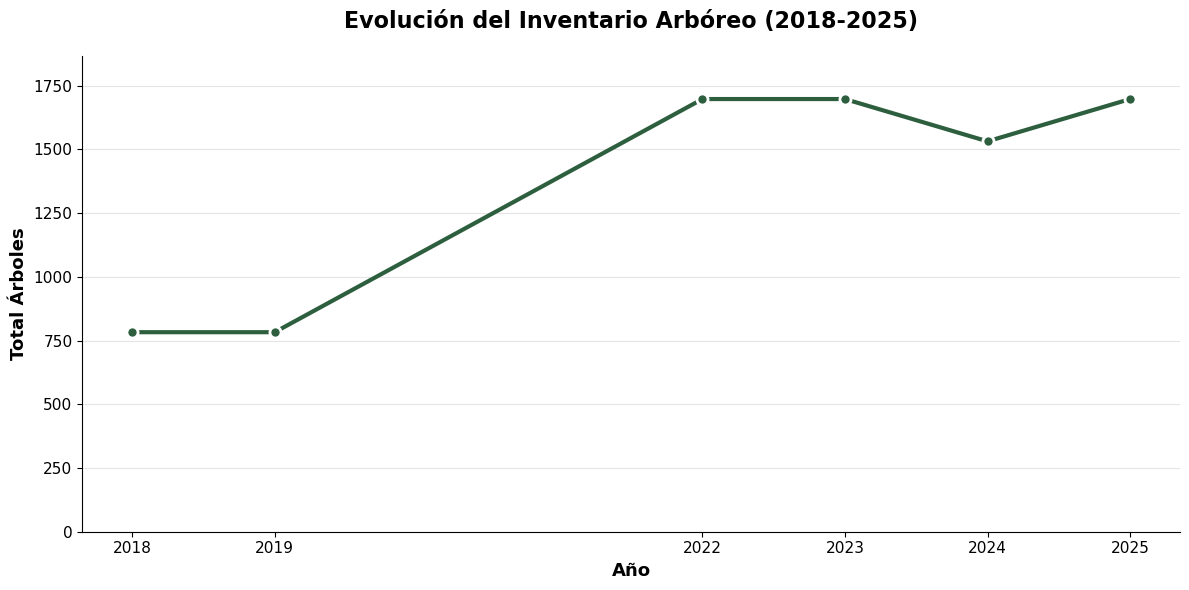


Registros por año:
ANIO MEDICION
2018     783
2019     783
2022    1698
2023    1698
2024    1532
2025    1698
Name: NUMERO ARBOL, dtype: int64


In [ ]:
# Contar árboles por año
arboles_por_anio = datos.groupby('ANIO MEDICION')['NUMERO ARBOL'].count()
 
# datos 
anios = arboles_por_anio.index
cantidades_anio = arboles_por_anio.values
 
# figura 
plt.figure(figsize=(12, 6))
 
# tráfico
plt.plot(anios, cantidades_anio, 
         marker='o',           # Puntos circulares
         linewidth=3,          # Línea más gruesa
         markersize=8,         # Puntos más grandes
         color='#2d5f3f',      # Verde oscuro UNA
         markerfacecolor='#2d5f3f',
         markeredgecolor='white',
         markeredgewidth=2)
 
# título 
plt.title('Evolución del Inventario Arbóreo (2018-2025)', 
          fontsize=16, fontweight='bold', pad=20)
 
# ejes
plt.xlabel('Año', fontsize=13, fontweight='bold')
plt.ylabel('Total Árboles', fontsize=13, fontweight='bold')
 
# eje Y 
plt.ylim(bottom=0, top=max(cantidades_anio) * 1.1)  # Un poco más arriba del máximo
 
# Grid horizontal 
plt.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.8, color='gray')
 
# Fondo 
plt.gca().set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
 

plt.xticks(anios, rotation=0, fontsize=11)
plt.yticks(fontsize=11)
 

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
 

plt.tight_layout()
 

plt.show()
 
# tabla de valores
print("\nRegistros por año:")
print(arboles_por_anio)

### Interpretación:

El gráfico muestra la evolución del esfuerzo de inventario a lo largo de los años. Se observa un incremento significativo en 2022, pasando de 783 registros anuales en 2018-2019 a 1,698 registros en 2022-2023. 

Este aumento no necesariamente indica que se plantaron más árboles, sino más bien que:
1. Se amplió la cobertura del censo a más áreas del campus
2. Se realizaron mediciones más frecuentes de los mismos individuos
3. Se mejoró la metodología de inventario

La ligera disminución en 2024 (1,532 registros) puede deberse a la remoción de algunos árboles por razones de seguridad o infraestructura.



## 5. Gráfico 3: Distribución de clases diamétricas (Histograma con filtrado)

Este gráfico muestra la distribución de tamaños (DAP) de los árboles **activos** en el año **2025**, el censo más reciente.

Árboles activos en 2025: 1517


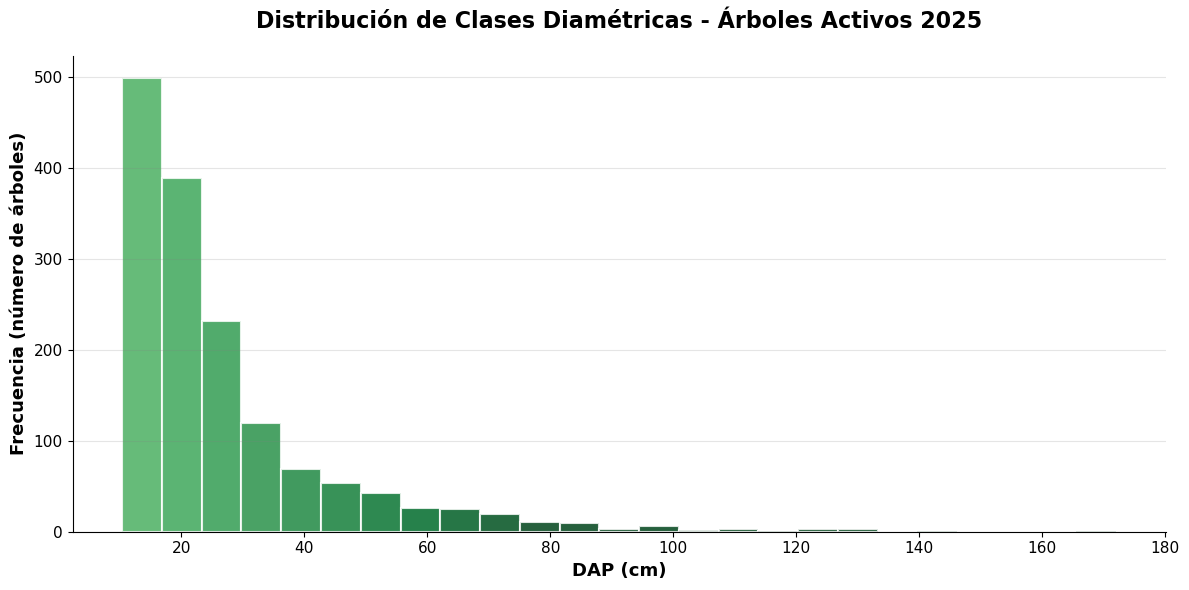


Estadísticas de DAP (2025):
Media: 26.96 cm
Mediana: 20.50 cm
Mínimo: 10.40 cm
Máximo: 172.00 cm


In [ ]:
# Solo árboles activos del año 2025
datos_2025 = datos[(datos['ANIO MEDICION'] == 2025) & 
                   (datos['ESTADO ARBOL'] == 'Activo')]
 
print(f"Árboles activos en 2025: {len(datos_2025)}")
 
# Crear figura
plt.figure(figsize=(12, 6))
 

n, bins, patches = plt.hist(datos_2025['DAP CM'].dropna(), 
                             bins=25, 
                             color="#103a26", 
                             edgecolor='white', 
                             alpha=0.85,
                             linewidth=1.5)
 
# barras con degradado
cm = plt.cm.Greens
for i, patch in enumerate(patches):
    patch.set_facecolor(cm(0.6 + 1 * i / len(patches)))
 
# Título y etiquetas
plt.title('Distribución de Clases Diamétricas - Árboles Activos 2025', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('DAP (cm)', fontsize=13, fontweight='bold')
plt.ylabel('Frecuencia (número de árboles)', fontsize=13, fontweight='bold')
 
#  horizontal
plt.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.8, color='gray')
 
# Fondo blanco
plt.gca().set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
 
# Quitar bordes superiores y derechos
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
 
# ticks
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
 
# diseño
plt.tight_layout()
 

plt.show()
 
# Estadísticas descriptivas
print("\nEstadísticas de DAP (2025):")
print(f"Media: {datos_2025['DAP CM'].mean():.2f} cm")
print(f"Mediana: {datos_2025['DAP CM'].median():.2f} cm")
print(f"Mínimo: {datos_2025['DAP CM'].min():.2f} cm")
print(f"Máximo: {datos_2025['DAP CM'].max():.2f} cm")

### Interpretación:

El histograma muestra una distribución típica de un bosque urbano joven con regeneración activa. La mayoría de los árboles tienen DAPs entre 10-30 cm, lo que indica:

1. **Predominancia de árboles jóvenes a medianos**: La mayor concentración está en las clases diamétricas pequeñas
2. **Curva de J invertida**: Es una distribución normal esperada en poblaciones forestales saludables con reclutamiento constante
3. **Presencia de árboles grandes**: Aunque menos numerosos, hay individuos con DAPs superiores a 100 cm, que son árboles maduros de gran valor ecológico y paisajístico

Esta estructura diamétrica sugiere un bosque urbano en buen estado de conservación, con procesos de regeneración natural activos y presencia de árboles de diferentes edades, lo cual es importante para la resiliencia del ecosistema.

 

## 6. Conclusiones

Este análisis del inventario arbóreo del Campus Omar Dengo de la UNA revela:

1. **Diversidad florística**: El campus alberga más de 100 especies diferentes, con una mezcla equilibrada de especies nativas (Guachipelín, Uruca, Itabo) y especies ornamentales introducidas (Mango).

2. **Evolución del inventario**: Se observa un incremento significativo en el esfuerzo de censo entre 2018 y 2025, pasando de ~780 registros anuales a más de 1,600, lo que refleja un mayor compromiso institucional con el monitoreo del patrimonio arbóreo.

3. **Estructura poblacional saludable**: La distribución diamétrica muestra una población con buena regeneración natural y presencia de árboles maduros, lo que es indicativo de un ecosistema urbano en buen estado.

4. **Captura de carbono significativa**: Las especies dominantes (Mango, Guachipelín, Uruca) contribuyen sustancialmente a la captura de carbono del campus, aportando a los objetivos institucionales de carbono neutralidad.

Este tipo de monitoreo continuo es fundamental para:
- La gestión sostenible del patrimonio arbóreo universitario
- El cumplimiento de compromisos ambientales institucionales
- La generación de conocimiento científico
- La educación ambiental de la comunidad universitaria
